# 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pyarrow

# caminhos relativos à raiz do projeto
RATINGS_PATH = "data/ratings_clean.parquet"
MOVIES_PATH  = "data/movies_clean.parquet"

ratings = pd.read_parquet(RATINGS_PATH)
movies  = pd.read_parquet(MOVIES_PATH)

print("ratings:", ratings.shape)
print("movies: ", movies.shape)
movies.head()

ratings: (100781, 4)
movies:  (9686, 5)


,movieId,title,genres,year,title_clean
0,1,Toy Story (1995),"Adventure, Animation, Children, Comedy, Fantasy",1995.0,Toy Story
1,2,Jumanji (1995),"Adventure, Children, Fantasy",1995.0,Jumanji
2,3,Grumpier Old Men (1995),"Comedy, Romance",1995.0,Grumpier Old Men
3,4,Waiting to Exhale (1995),"Comedy, Drama, Romance",1995.0,Waiting to Exhale
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II


## 2. Análise Exploratória



### 2.1 Distribuição das avaliações

Buscamos entender como as notas se distribuem globalmente.
Nossa hipótese inicial era de distribuição normal centrada entre 2.5 e 3.5,
mas sistemas de recomendação costumam apresentar viés de positividade —
usuários tendem a avaliar o que escolheram assistir, e escolhem assistir
o que já têm algum interesse.
|

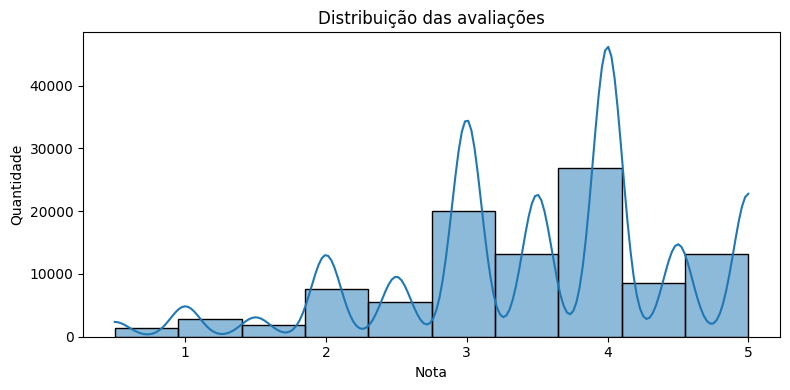

Média:          3.50
Mediana:        3.50
Desvio padrão:  1.04
Mínimo:         0.5
Máximo:         5.0


In [2]:
# distribuição das notas
plt.figure(figsize=(8, 4))
sns.histplot(ratings["rating"], bins=10, kde=True)
plt.title("Distribuição das avaliações")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

print(f"Média:          {ratings['rating'].mean():.2f}")
print(f"Mediana:        {ratings['rating'].median():.2f}")
print(f"Desvio padrão:  {ratings['rating'].std():.2f}")
print(f"Mínimo:         {ratings['rating'].min()}")
print(f"Máximo:         {ratings['rating'].max()}")

### 2.2 Avaliações por usuário

Investigamos a distribuição de atividade entre usuários. A hipótese é de
cauda longa — poucos usuários hiper-ativos concentrando a maior parte das
avaliações, padrão comum em sistemas sociais (lei de potência).

Isso importa para o modelo colaborativo: usuários com muitas avaliações
têm peso desproporcional na matriz usuário × filme.

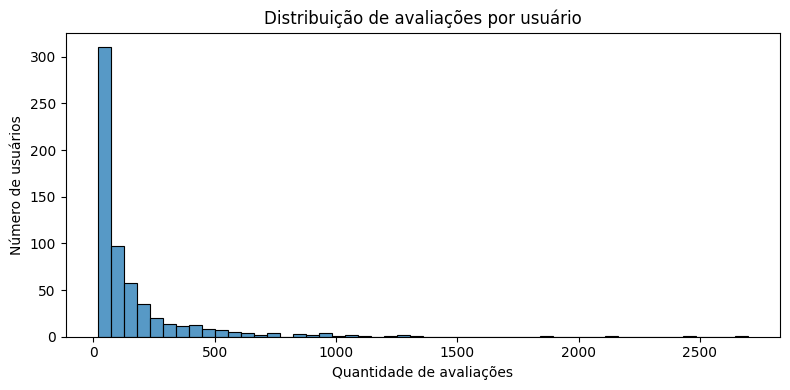

Média:   165.2
Mediana: 70.5
Máximo:  2696
Mínimo:  20

Top 10 usuários concentram: 16.3% das avaliações
userId
414    2696
599    2474
474    2108
448    1862
274    1346
Name: rating, dtype: int64


In [3]:
avaliacoes_por_usuario = ratings.groupby("userId")["rating"].count()

plt.figure(figsize=(8, 4))
sns.histplot(avaliacoes_por_usuario, bins=50, kde=False)
plt.title("Distribuição de avaliações por usuário")
plt.xlabel("Quantidade de avaliações")
plt.ylabel("Número de usuários")
plt.tight_layout()
plt.show()

print(f"Média:   {avaliacoes_por_usuario.mean():.1f}")
print(f"Mediana: {avaliacoes_por_usuario.median():.1f}")
print(f"Máximo:  {avaliacoes_por_usuario.max()}")
print(f"Mínimo:  {avaliacoes_por_usuario.min()}")

# os 10 usuários mais ativos concentram quanto do total?
top10 = avaliacoes_por_usuario.nlargest(10).sum()
total = avaliacoes_por_usuario.sum()
print(f"\nTop 10 usuários concentram: {top10/total*100:.1f}% das avaliações")

# quem é esse usuário que avaliou mais?
print(avaliacoes_por_usuario.nlargest(5))

### 2.3 Avaliações por filme

Verificamos como as avaliações se distribuem entre os filmes — o mesmo
padrão de cauda longa é esperado, refletindo o fenômeno do blockbuster:
poucos filmes concentram a atenção da maioria.

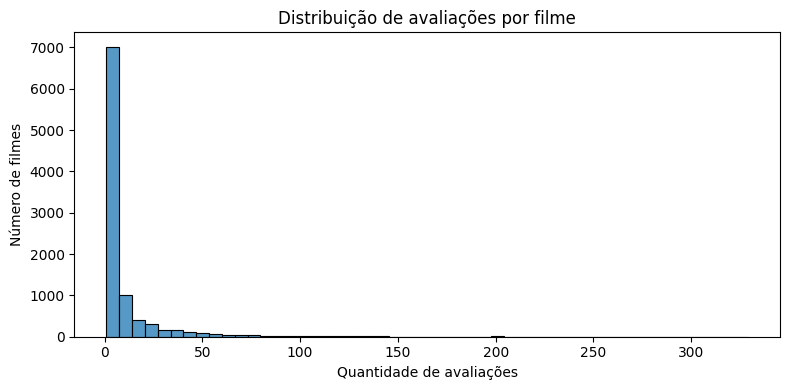

Média:   10.4
Mediana: 3.0
Máximo:  329

Filmes com menos de 10 avaliações: 7417 (76.6%)


In [4]:
avaliacoes_por_filme = ratings.groupby("movieId")["rating"].count()

plt.figure(figsize=(8, 4))
sns.histplot(avaliacoes_por_filme, bins=50, kde=False)
plt.title("Distribuição de avaliações por filme")
plt.xlabel("Quantidade de avaliações")
plt.ylabel("Número de filmes")
plt.tight_layout()
plt.show()

print(f"Média:   {avaliacoes_por_filme.mean():.1f}")
print(f"Mediana: {avaliacoes_por_filme.median():.1f}")
print(f"Máximo:  {avaliacoes_por_filme.max()}")

# qual % dos filmes tem menos de 10 avaliações?
poucos = (avaliacoes_por_filme < 10).sum()
total = len(avaliacoes_por_filme)
print(f"\nFilmes com menos de 10 avaliações: {poucos} ({poucos/total*100:.1f}%)")

Com issso, podemos ver que são poucos os filmes com quantidade de avaliações suficiente para serem consideradas. Com a mediana sendo 3, significa que metade dos filmes recebe no máximo 3 avaliações. Por isso, podemos definir que vamos usar apenas os filmes mais populares. Isso pode manter as recomendações numa bolha de blockbusters, mas a quantidade de avaliações nos oferece mais confiança na hora de recomendar.
Isso será considerado apenas numa primeira fase de elaboração, podemos vir a pensar em soluções mais elaboradas no futuro.


### 2.4 Distribuição temporal

Analisamos como filmes e avaliações se distribuem por década de lançamento.
Duas hipóteses em investigação:
- **Recency bias**: filmes recentes recebem mais avaliações por terem
  audiência contemporânea.
- **Survivorship bias**: filmes antigos recebem notas mais altas porque
  apenas os clássicos sobreviveram ao esquecimento.

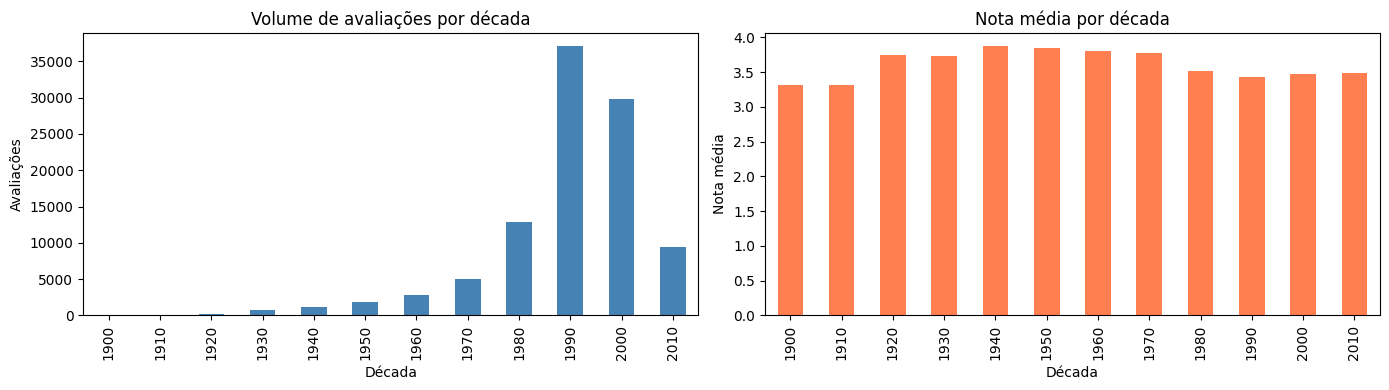

 decade  num_ratings  num_filmes  avg_rating
   1900            8           3    3.312500
   1910            8           7    3.312500
   1920          125          37    3.740000
   1930          687         134    3.733624
   1940         1101         194    3.870572
   1950         1783         276    3.845485
   1960         2857         398    3.808365
   1970         4994         497    3.775631
   1980        12911        1174    3.518279
   1990        37081        2204    3.434576
   2000        29766        2848    3.465750
   2010         9460        1914    3.489376


In [5]:
# avaliações por década de lançamento
movies_ratings = ratings.merge(movies[["movieId", "year"]], on="movieId")
movies_ratings["decade"] = (movies_ratings["year"] // 10 * 10).astype(int)

por_decada = movies_ratings.groupby("decade").agg(
    num_ratings=("rating", "count"),
    num_filmes=("movieId", "nunique"),
    avg_rating=("rating", "mean")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

por_decada.plot(x="decade", y="num_ratings", kind="bar", ax=axes[0], legend=False, color="steelblue")
axes[0].set_title("Volume de avaliações por década")
axes[0].set_xlabel("Década")
axes[0].set_ylabel("Avaliações")

por_decada.plot(x="decade", y="avg_rating", kind="bar", ax=axes[1], legend=False, color="coral")
axes[1].set_title("Nota média por década")
axes[1].set_xlabel("Década")
axes[1].set_ylabel("Nota média")

plt.tight_layout()
plt.show()

print(por_decada.to_string(index=False))

### 2.5 Análise por gênero

Investigamos se gêneros recebem notas sistematicamente diferentes —
o que indicaria viés de gênero no modelo de popularidade.

Como cada filme pertence a múltiplos gêneros no MovieLens, aplicamos
`explode()` para que cada filme contribua para a média de cada um dos
seus gêneros individualmente.

Além da nota média, calculamos o desvio padrão por gênero — uma medida
de **polarização**: desvio alto indica que as pessoas discordam sobre
aquele gênero (ame ou odeie), desvio baixo indica consenso.

In [6]:
# explodir gêneros
movies_exploded = movies.copy()
movies_exploded["genres"] = movies_exploded["genres"].str.split(", ")
movies_exploded = movies_exploded.explode("genres")

# juntar com ratings
genero_ratings = movies_exploded.merge(ratings, on="movieId")

# nota média e volume por gênero
por_genero = (
    genero_ratings.groupby("genres")
    .agg(
        num_ratings=("rating", "count"),
        num_filmes=("movieId", "nunique"),
        avg_rating=("rating", "mean"),
        std_rating=("rating", "std"),
    )
    .reset_index()
    .sort_values("avg_rating", ascending=False)
    .round(2)
)
por_genero["ratings_por_filme"] = (
    por_genero["num_ratings"] / por_genero["num_filmes"]
).round(1)

print(por_genero.sort_values("ratings_por_filme", ascending=False).to_string(index=False))

     genres  num_ratings  num_filmes  avg_rating  std_rating  ratings_por_filme
  Adventure        24161        1262        3.51        1.03               19.1
     Sci-Fi        17237         978        3.46        1.07               17.6
     Action        30631        1827        3.45        1.05               16.8
    Fantasy        11834         778        3.49        1.04               15.2
   Thriller        26447        1887        3.49        1.03               14.0
      Crime        16681        1196        3.66        0.99               13.9
   Children         9208         664        3.41        1.06               13.9
    Mystery         7674         573        3.63        1.01               13.4
        War         4859         381        3.81        0.98               12.8
    Musical         4138         333        3.56        0.99               12.4
    Western         1930         167        3.58        1.01               11.6
  Animation         6988         610    

Podemos ver aqui que as avaliações médias não fogem, novamente, dos valores entre 3 e 4.
Outra medida importante é o desvio padrão, dando um teor de "ame ou odeie" para alguns gêneros cujo desvio padrão acaba sendo mais alto (como Horror e Comédia).
Podemos analisar também quantas avaliações cada gênero recebe:
* Adventure, Sci-Fi e Action no topo - são os gêneros blockbuster por natureza. Poucos filmes mas muito assistidos e avaliados. O público é amplo e engajado.
* Documentary no fundo com 2.8 - É o gênero com maior catálogo relativo ao engajamento. Muitos documentários existem mas poucos recebem atenção fora do público específico. E possui combinação curiosa: segunda maior nota média (3.80) mas menor densidade. É survivorship bias puro — só os documentários excepcionais chegam ao radar da maioria.
* Horror com 7.5 - baixa densidade E menor nota média. É o gênero mais problemático já que possui pouco engajamento qualificado, opiniões polarizadas. 
* Film-Noir -  nota mais alta de todas (3.92), mas densidade mediana (10.2) e apenas 85 filmes. É o gênero mais consistentemente bem avaliado e mais nichado ao mesmo tempo. Qualquer recomendação de Film-Noir vai ser certeira — mas vai atender pouquíssimos usuários.


### 2.6 Volume de avaliações × nota média

Investigamos se filmes com mais avaliações tendem a ter notas mais altas
ou mais baixas. A hipótese central é a **lei dos grandes números**: com
mais avaliações, a média converge para um valor mais estável e confiável,
reduzindo o impacto de avaliações extremas isoladas.

Isso justifica o uso da **fórmula bayesiana do IMDb** na etapa de
modelagem, que penaliza filmes com poucas avaliações puxando a nota
em direção à média global.

  faixa  num_filmes  avg_rating  std_rating
   1-10        7565        3.21        0.94
  11-50        1685        3.39        0.51
 51-100         302        3.60        0.38
101-200         116        3.78        0.34
201-500          18        4.07        0.23


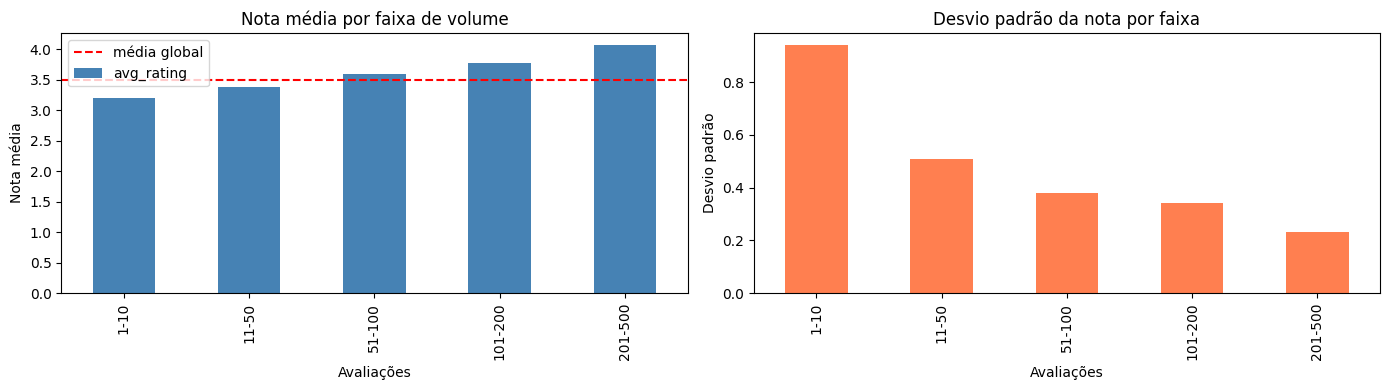

In [7]:
# agrupar filmes por faixas de volume de avaliações
avaliacoes_por_filme = ratings.groupby("movieId").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean")
).reset_index()

# criar faixas de volume
bins = [0, 10, 50, 100, 200, 500, float("inf")]
labels = ["1-10", "11-50", "51-100", "101-200", "201-500", "500+"]

avaliacoes_por_filme["faixa"] = pd.cut(
    avaliacoes_por_filme["num_ratings"],
    bins=bins,
    labels=labels
)

por_faixa = (
    avaliacoes_por_filme.groupby("faixa", observed=True)
    .agg(
        num_filmes=("movieId", "count"),
        avg_rating=("avg_rating", "mean"),
        std_rating=("avg_rating", "std")
    )
    .reset_index()
    .round(2)
)

print(por_faixa.to_string(index=False))

# visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

por_faixa.plot(x="faixa", y="avg_rating", kind="bar", ax=axes[0], legend=False, color="steelblue")
axes[0].set_title("Nota média por faixa de volume")
axes[0].set_xlabel("Avaliações")
axes[0].set_ylabel("Nota média")
axes[0].axhline(y=ratings["rating"].mean(), color="red", linestyle="--", label="média global")
axes[0].legend()

por_faixa.plot(x="faixa", y="std_rating", kind="bar", ax=axes[1], legend=False, color="coral")
axes[1].set_title("Desvio padrão da nota por faixa")
axes[1].set_xlabel("Avaliações")
axes[1].set_ylabel("Desvio padrão")

plt.tight_layout()
plt.show()

Os dados aqui confirmam a lei dos grandes números; quanto mais avaliações temos, mais constantes são as avaliações (menor desvio padrão) e por isso são mais confiáveis.

### 2.7 Perfil de avaliação por nível de atividade

Investigamos se usuários mais ativos são mais críticos ou mais generosos
que usuários casuais. Hipóteses em conflito:
- Usuários ativos desenvolvem critério com o repertório → mais críticos
- Usuários casuais só avaliam o que amaram → média artificialmente alta

O desvio padrão por faixa indica se usuários casuais tendem a avaliações
mais extremas (bimodal) ou se o padrão é uniforme entre os grupos.

   faixa  num_usuarios  avg_rating  std_rating
   20-50            14        3.43        0.92
  51-100           219        3.73        0.94
 101-200           133        3.71        0.93
 201-500           111        3.62        0.93
501-1000            90        3.63        0.91
   1000+            43        3.34        0.91


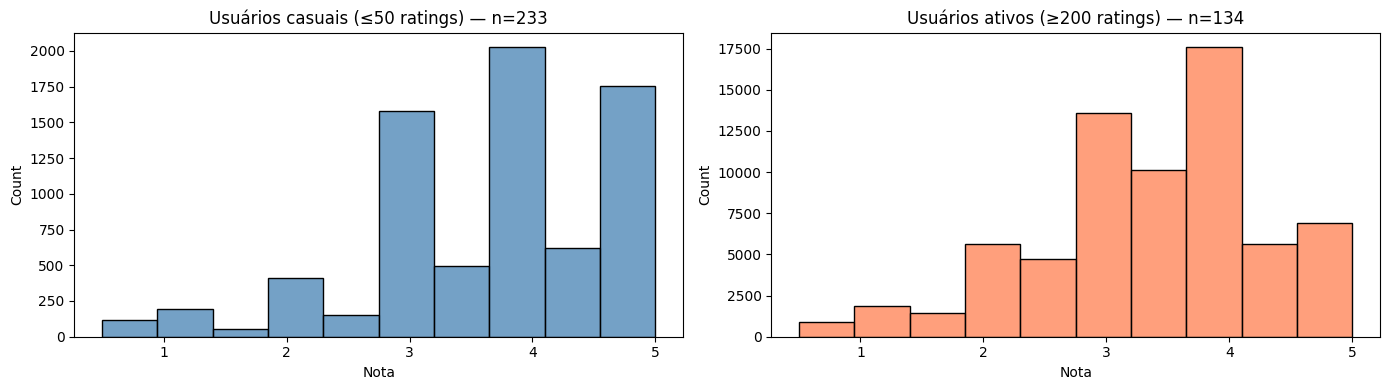

In [8]:
# nota média por usuário e volume de avaliações
perfil_usuario = ratings.groupby("userId").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean"),
    std_rating=("rating", "std")
).reset_index().round(2)

# faixas de atividade
bins   = [0, 20, 50, 100, 200, 500, float("inf")]
labels = ["20-50", "51-100", "101-200", "201-500", "501-1000", "1000+"]

perfil_usuario["faixa"] = pd.cut(
    perfil_usuario["num_ratings"],
    bins=bins,
    labels=labels
)

por_faixa_usuario = (
    perfil_usuario.groupby("faixa", observed=True)
    .agg(
        num_usuarios=("userId", "count"),
        avg_rating=("avg_rating", "mean"),
        std_rating=("std_rating", "mean")
    )
    .reset_index()
    .round(2)
)

print(por_faixa_usuario.to_string(index=False))

# visualizar distribuição de notas para usuários casuais vs ativos
casualis  = perfil_usuario[perfil_usuario["num_ratings"] <= 50]["userId"]
ativos    = perfil_usuario[perfil_usuario["num_ratings"] >= 200]["userId"]

ratings_casuais = ratings[ratings["userId"].isin(casualis)]["rating"]
ratings_ativos  = ratings[ratings["userId"].isin(ativos)]["rating"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(ratings_casuais, bins=10, ax=axes[0], color="steelblue")
axes[0].set_title(f"Usuários casuais (≤50 ratings) — n={len(casualis)}")
axes[0].set_xlabel("Nota")

sns.histplot(ratings_ativos, bins=10, ax=axes[1], color="coral")
axes[1].set_title(f"Usuários ativos (≥200 ratings) — n={len(ativos)}")
axes[1].set_xlabel("Nota")

plt.tight_layout()
plt.show()

Aqui a intenção era ver se usuários que avaliam muitos filmes tendem a ser mais críticos e se usuários que avaliam pouco tendem mais aos extremos, o que parece uma hipótese plausível. Mas os desvios padrões bastante semeplantes e as médias flutuando pouco, esse comportamento esperado não é observado.

## 3. Análise de Anomalias

Anomalias não são necessariamente erros — são padrões que fogem do
comportamento esperado e podem distorcer o modelo se não tratados
conscientemente.



### 3.1 Anomalias de usuário

Identificamos três categorias de usuários anômalos:
- **Sempre positivos**: média alta + desvio baixo → não discriminam entre filmes, reduzindo sua utilidade para o modelo colaborativo
- **Sempre negativos**: média baixa + desvio baixo → comportamento oposto, igualmente pouco informativo
- **Volume extremo**: top 1% em número de avaliações → influência desproporcional na matriz

In [9]:
# perfil completo de cada usuário
perfil_usuario = ratings.groupby("userId").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean"),
    std_rating=("rating", "std")
).reset_index().round(2)

# anomalia 1 — usuários que só elogiam (média alta + desvio baixo)
sempre_positivo = perfil_usuario[
    (perfil_usuario["avg_rating"] >= 4.5) &
    (perfil_usuario["std_rating"] <= 0.5)
].sort_values("avg_rating", ascending=False)

# anomalia 2 — usuários que só criticam (média baixa + desvio baixo)
sempre_negativo = perfil_usuario[
    (perfil_usuario["avg_rating"] <= 2.0) &
    (perfil_usuario["std_rating"] <= 0.5)
].sort_values("avg_rating")

# anomalia 3 — usuários com volume extremo
volume_extremo = perfil_usuario[
    perfil_usuario["num_ratings"] >= perfil_usuario["num_ratings"].quantile(0.99)
].sort_values("num_ratings", ascending=False)

print(f"Sempre positivos: {len(sempre_positivo)}")
print(sempre_positivo.head())

print(f"\nSempre negativos: {len(sempre_negativo)}")
print(sempre_negativo.head())

print(f"\nVolume extremo (top 1%): {len(volume_extremo)}")
print(volume_extremo)

Sempre positivos: 6
     userId  num_ratings  avg_rating  std_rating
52       53           20        5.00        0.00
514     515           26        4.85        0.34
24       25           26        4.81        0.38
522     523           75        4.69        0.45
347     348           55        4.67        0.43

Sempre negativos: 0
Empty DataFrame
Columns: [userId, num_ratings, avg_rating, std_rating]
Index: []

Volume extremo (top 1%): 7
     userId  num_ratings  avg_rating  std_rating
413     414         2696        3.39        0.93
598     599         2474        2.64        0.82
473     474         2108        3.40        0.83
447     448         1862        2.85        1.03
273     274         1346        3.24        0.76
609     610         1302        3.69        0.86
67       68         1260        3.23        0.90


### 3.2 Anomalias de filme

Analisamos quatro categorias de filmes com comportamento estatístico atípico,
usando threshold de **5 avaliações mínimas** — abaixo disso a variância é
alta demais para confiar no sinal, acima de 10 estaríamos tratando 76% do
catálogo como anômalo.

In [10]:
# perfil completo de cada filme
perfil_filme = ratings.groupby("movieId").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean"),
    std_rating=("rating", "std")
).reset_index().round(2)

# juntar com nome do filme
perfil_filme = perfil_filme.merge(
    movies[["movieId", "title_clean", "genres", "year"]],
    on="movieId"
)

THRESHOLD = 5

# anomalia 1 — média alta com poucas avaliações
media_alta_poucos = perfil_filme[
    (perfil_filme["num_ratings"] < THRESHOLD) &
    (perfil_filme["avg_rating"] >= 4.5)
].sort_values("avg_rating", ascending=False)

# anomalia 2 — média baixa com poucas avaliações
media_baixa_poucos = perfil_filme[
    (perfil_filme["num_ratings"] < THRESHOLD) &
    (perfil_filme["avg_rating"] <= 2.0)
].sort_values("avg_rating")

# anomalia 3 — média alta com muitas avaliações (filmes consensualmente amados)
media_alta_muitos = perfil_filme[
    (perfil_filme["num_ratings"] >= 50) &
    (perfil_filme["avg_rating"] >= 4.3)
].sort_values("avg_rating", ascending=False)

# anomalia 4 — média baixa com muitas avaliações (blockbusters decepcionantes)
media_baixa_muitos = perfil_filme[
    (perfil_filme["num_ratings"] >= 50) &
    (perfil_filme["avg_rating"] <= 2.5)
].sort_values("avg_rating")

print(f"Média alta + poucas avaliações: {len(media_alta_poucos)}")
print(f"Média baixa + poucas avaliações: {len(media_baixa_poucos)}")
print(f"Média alta + muitas avaliações:  {len(media_alta_muitos)}")
print(f"Média baixa + muitas avaliações: {len(media_baixa_muitos)}")

print("\n--- Média alta + poucas avaliações (top 5) ---")
print(media_alta_poucos[["title_clean", "year", "genres", "num_ratings", "avg_rating"]].head())

print("\n--- Média baixa + poucas avaliações (top 5) ---")
print(media_baixa_poucos[["title_clean", "year", "genres", "num_ratings", "avg_rating"]].head())

print("\n--- Consensualmente amados ---")
print(media_alta_muitos[["title_clean", "year", "genres", "num_ratings", "avg_rating"]].head(10))

print("\n--- Blockbusters decepcionantes ---")
print(media_baixa_muitos[["title_clean", "year", "genres", "num_ratings", "avg_rating"]].head(10))

Média alta + poucas avaliações: 691
Média baixa + poucas avaliações: 997
Média alta + muitas avaliações:  1
Média baixa + muitas avaliações: 2

--- Média alta + poucas avaliações (top 5) ---
                                    title_clean    year  \
9536                      Bobik Visiting Barbos  1977.0   
9534        In the blue sea, in the white foam.  1984.0   
9533  On the Trail of the Bremen Town Musicians  1973.0   
9531                         Gena the Crocodile  1969.0   
9523                                  Obsession  1965.0   

                              genres  num_ratings  avg_rating  
9536               Animation, Comedy            1         5.0  
9534    Animation, Children, Fantasy            1         5.0  
9533  Adventure, Animation, Children            1         5.0  
9531             Animation, Children            1         5.0  
9523                          Comedy            1         5.0  

--- Média baixa + poucas avaliações (top 5) ---
                     

## 4. Resumo dos Insights e Decisões

| Insight | Implicação para o modelo |
|---|---|
| Viés de positividade (pico em 4.0) | Escala real entre 3.3–3.9; média bruta pouco discriminativa |
| Cauda longa de usuários | Normalização por usuário necessária no collaborative filtering |
| Survivorship bias em filmes antigos | Nota média não é proxy confiável de qualidade universal |
| Horror: menor nota + maior desvio | Gêneros polarizados precisam de perfil individual, não média |
| Usuários hiper-ativos mais críticos | Normalização por usuário equaliza influência |
| 6 usuários sempre positivos | Manter; normalização reduz influência naturalmente |
| Lei dos grandes números confirmada | Fórmula bayesiana do IMDb justificada para ranking |